In [1]:
run /Users/aguinot/Documents/rubin/rho_leakage.py

In [4]:
from glob import glob
import os

from astropy.io import fits
import numpy as np

import treecorr as tc

In [3]:
import matplotlib.pyplot as plt

In [41]:
pixel_scale = 0.11
n_patches = 30
seed = 42

In [6]:
all_path = glob("/Users/aguinot/Documents/roman/piff_5deg2/hsm_*.fits")

In [161]:
merge_cat_path = "/Users/aguinot/Documents/roman/piff_5deg2/merged_cat.npy"
if not os.path.exists(merge_cat_path):
    all_cat = []
    for path in all_path:
        with fits.open(path) as hdul:
            data = hdul[1].data
            all_cat.append(np.asanyarray(data))
    cat = np.concatenate(all_cat)
    np.save(merge_cat_path, cat)
else:
    cat = np.load(merge_cat_path, allow_pickle=True)

In [ ]:
mean_ra = np.mean(cat["ra"])
mean_dec = np.mean(cat["dec"])

snr_min = 50
good_stars = (cat["snr"] > snr_min) & (cat["flux"] > 0) & (cat["flag_psf"] == 0) & (cat["flag_data"] == 0) & (cat["flag_model"] == 0)

ra = cat["ra"][good_stars]
dec = cat["dec"][good_stars]
e1_star = cat["g1_data"][good_stars]
e2_star = cat["g2_data"][good_stars]
T_star = cat["T_data"][good_stars]
e1_psf = cat["g1_model"][good_stars]
e2_psf = cat["g2_model"][good_stars]
T_psf = cat["T_model"][good_stars]
de1 = e1_star - e1_psf
de2 = e2_star - e2_psf
dT = (T_star - T_psf)/T_psf

x = cat["x"][good_stars]
y = cat["y"][good_stars]
u = cat["u"][good_stars]
v = cat["v"][good_stars]

flux = cat["flux"][good_stars]
log_flux = np.log10(flux)
snr = cat["snr"][good_stars]

In [167]:
np.sum(good_stars)/len(cat), np.sum(good_stars), len(cat)

(np.float64(0.6559779931023156), np.int64(15977), 24356)

In [96]:
med_flux = np.median(flux)
med_log_flux = np.median(log_flux)

In [97]:
def med_sub(x):
    return np.median(x) - med_flux

def med_sub_log(x):
    return np.median(x) - med_log_flux

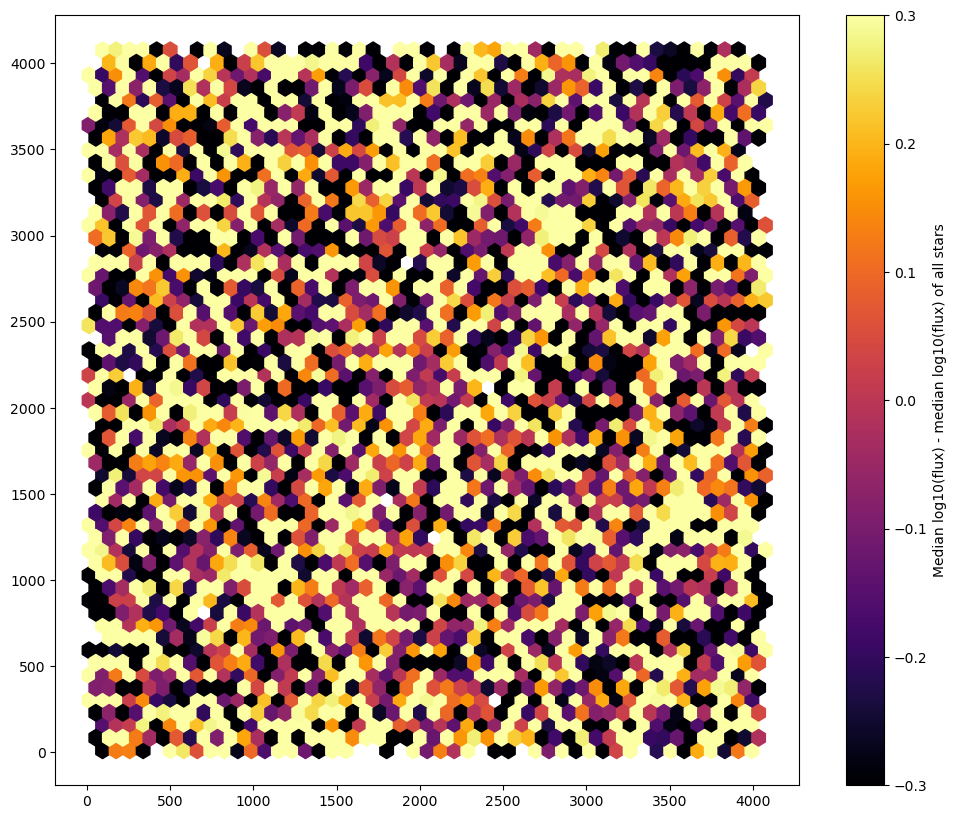

In [98]:
plt.figure(figsize=(12, 10))
plt.hexbin(x, y, C=log_flux, reduce_C_function=med_sub_log, gridsize=50, cmap="inferno", vmin=-0.3, vmax=0.3)
plt.colorbar(label="Median log10(flux) - median log10(flux) of all stars")

Text(0.5, 1.0, 'Number of stars per bin')

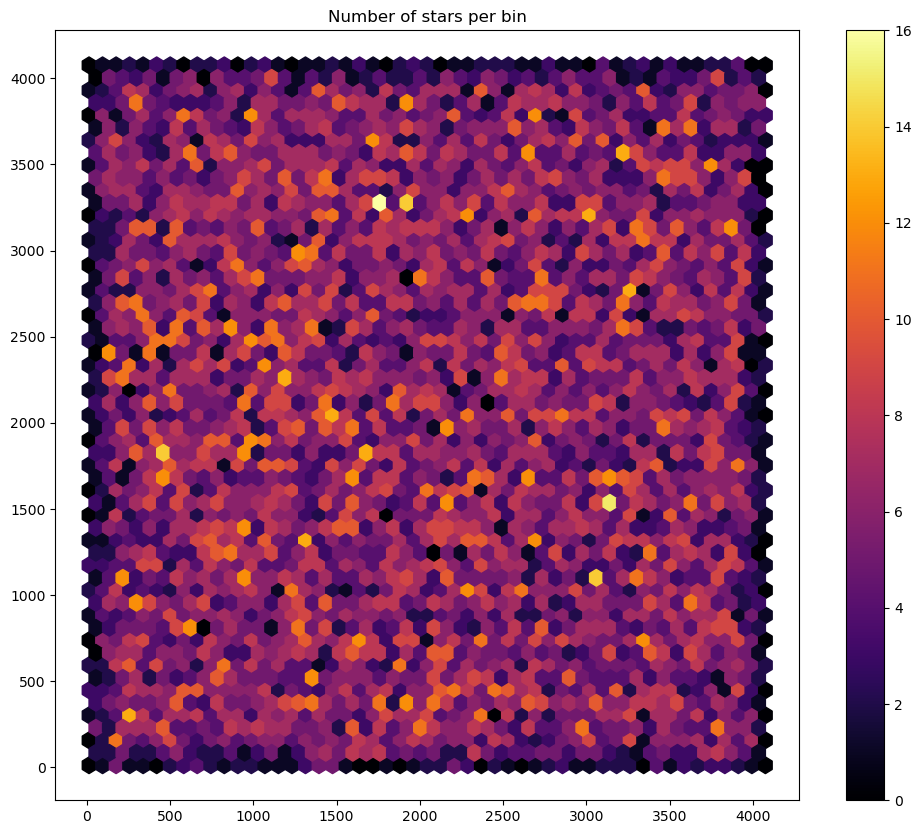

In [99]:
plt.figure(figsize=(12, 10))
plt.hexbin(x, y, gridsize=50, cmap="inferno")
plt.colorbar()
plt.title("Number of stars per bin")

Text(0.5, 1.0, 'T_star')

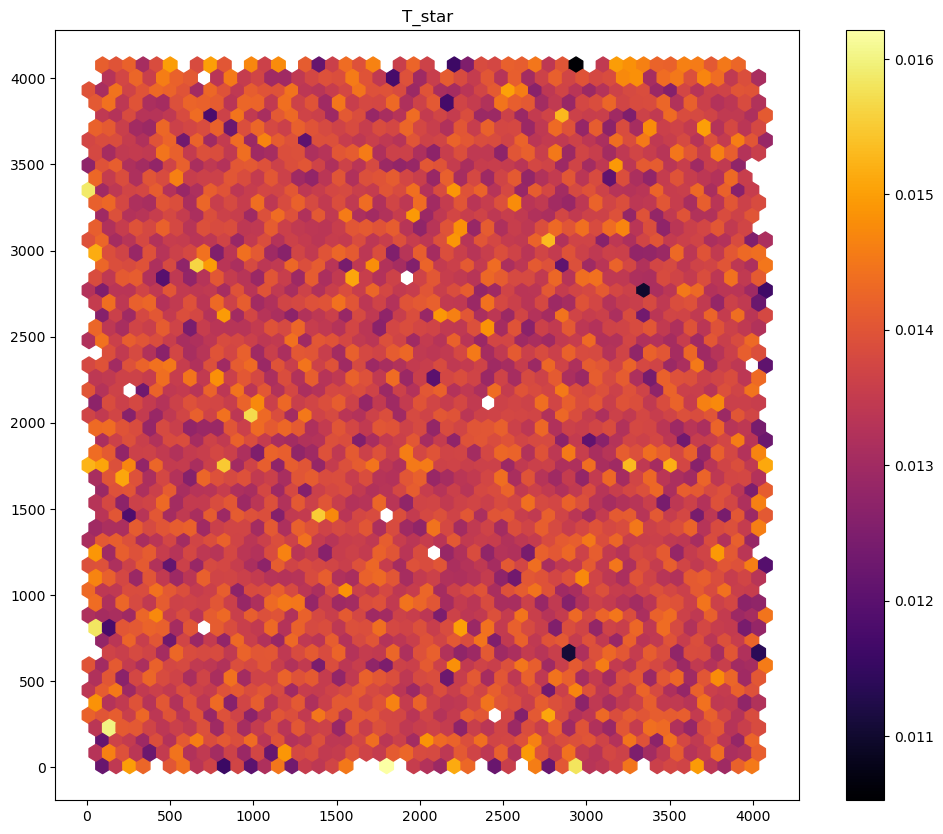

In [100]:
plt.figure(figsize=(12, 10))
plt.hexbin(x, y, C=T_star, gridsize=50, cmap="inferno")
plt.colorbar()
plt.title("T_star")

Text(0.5, 1.0, 'e1_star')

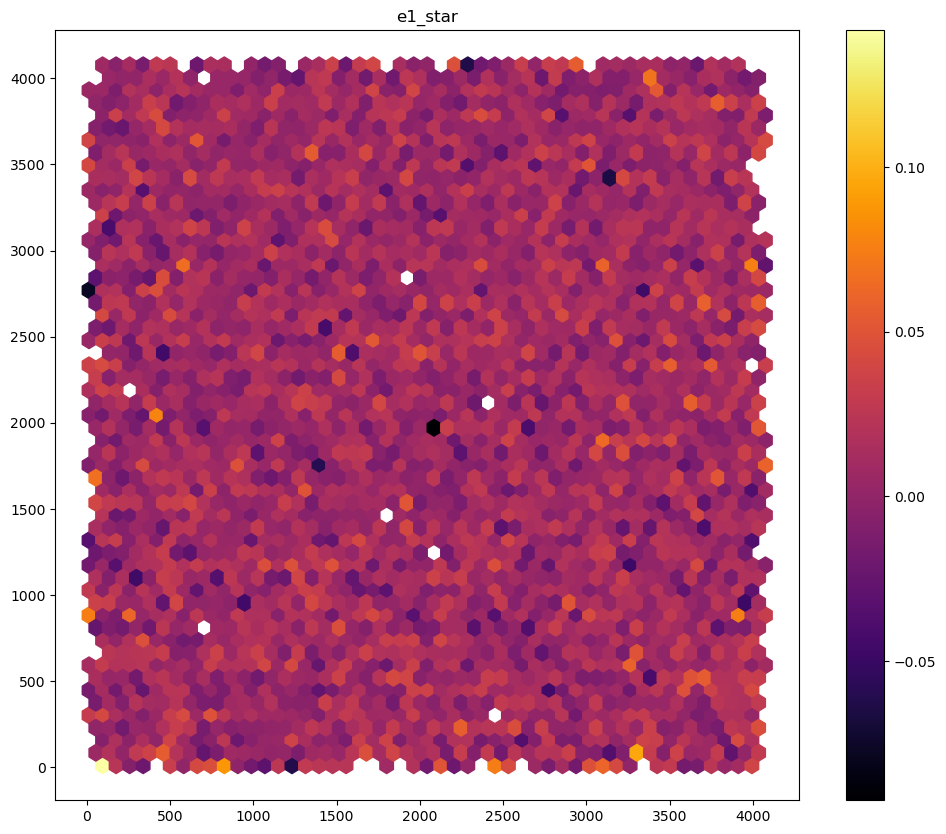

In [101]:
plt.figure(figsize=(12, 10))
plt.hexbin(x, y, C=e1_star, gridsize=50, cmap="inferno")
plt.colorbar()
plt.title("e1_star")

Text(0.5, 1.0, 'e2_star')

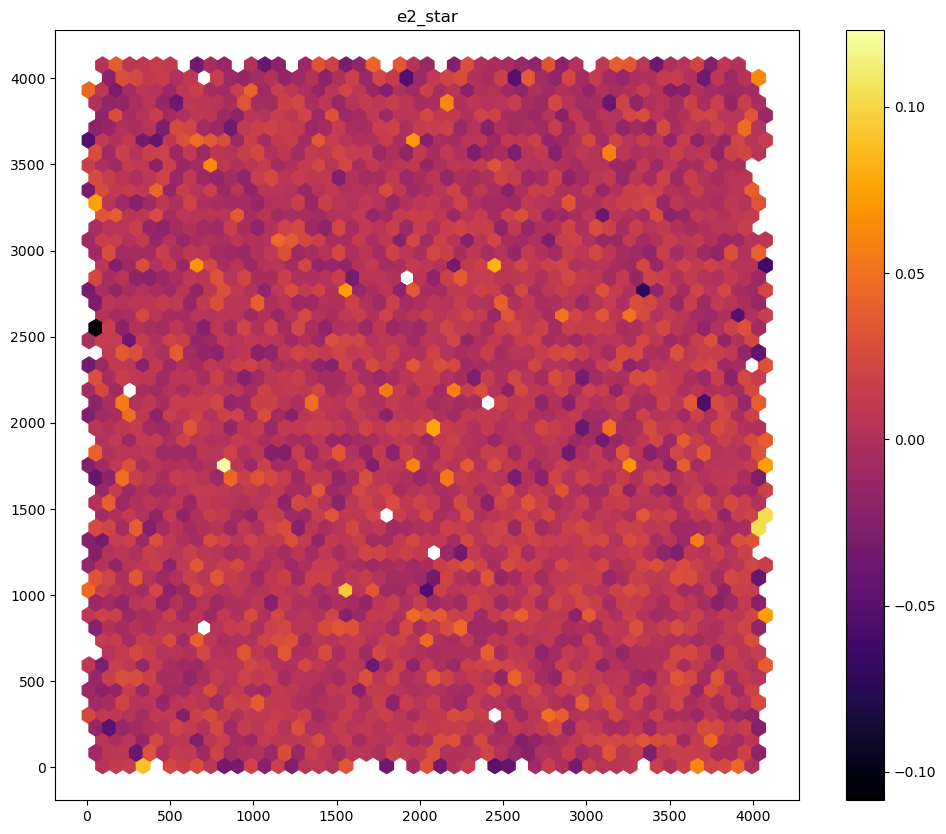

In [102]:
plt.figure(figsize=(12, 10))
plt.hexbin(x, y, C=e2_star, gridsize=50, cmap="inferno")
plt.colorbar()
plt.title("e2_star")

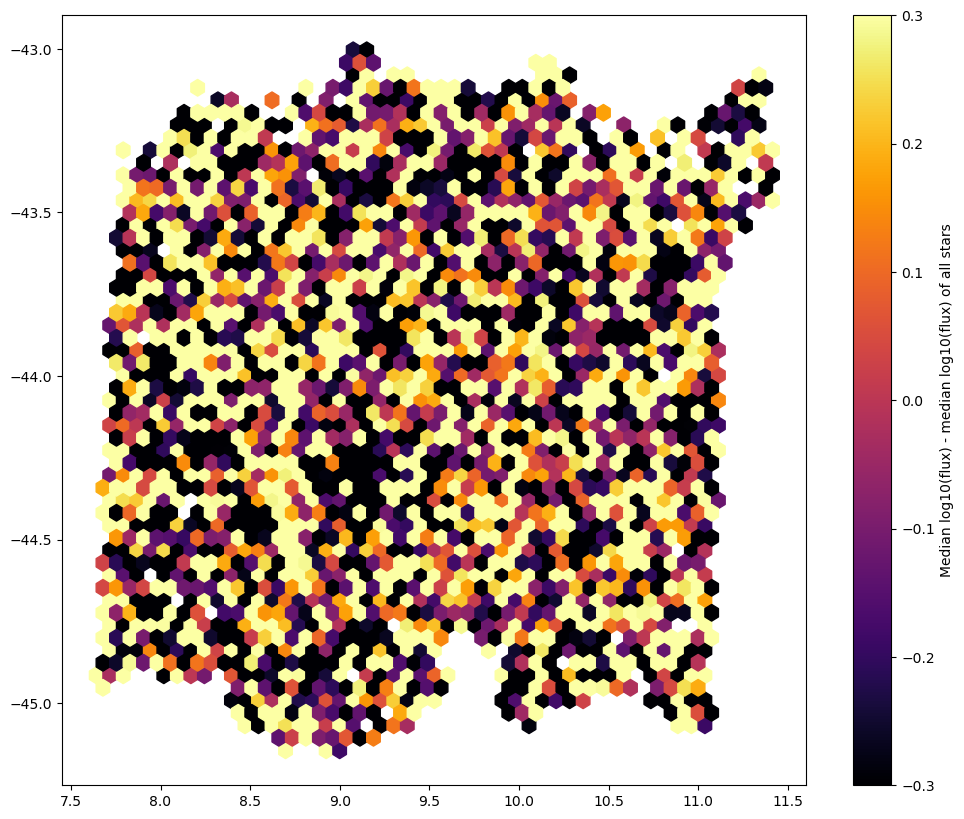

In [103]:
plt.figure(figsize=(12, 10))
plt.hexbin(ra, dec, C=log_flux, reduce_C_function=med_sub_log, gridsize=50, cmap="inferno", vmin=-0.3, vmax=0.3)
plt.colorbar(label="Median log10(flux) - median log10(flux) of all stars")

Text(0, 0.5, 'Dec (deg)')

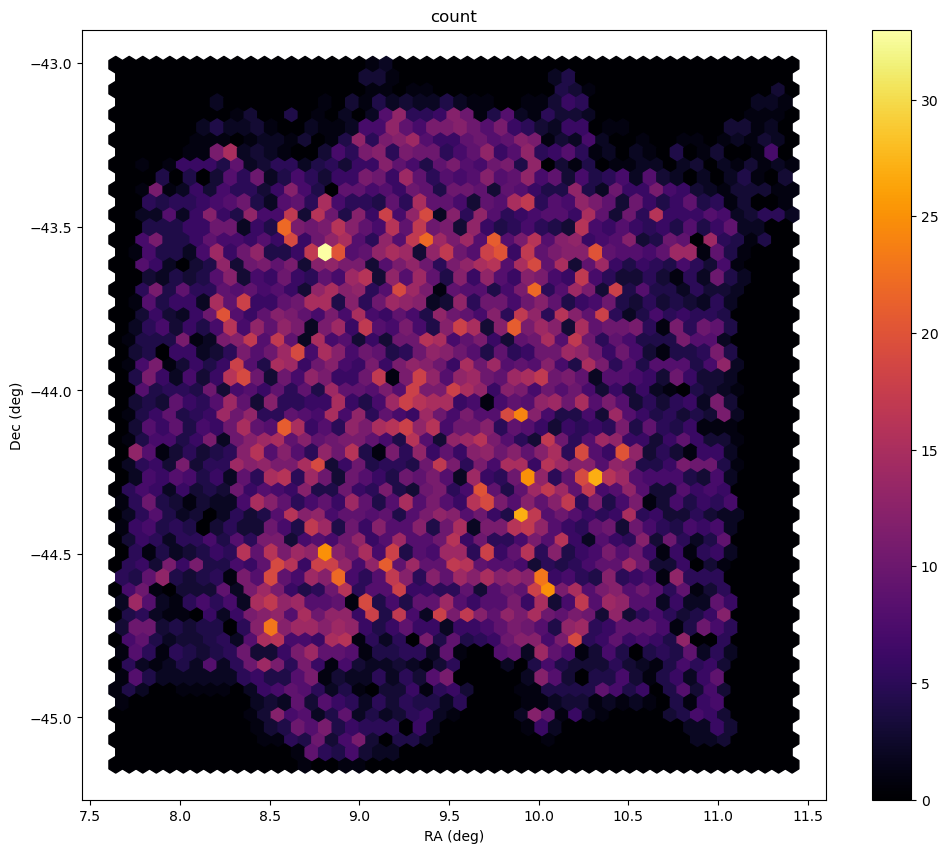

In [152]:
plt.figure(figsize=(12, 10))
plt.hexbin(ra, dec, gridsize=50, cmap="inferno")
plt.colorbar()
plt.title("count")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")

Text(0, 0.5, 'Dec (deg)')

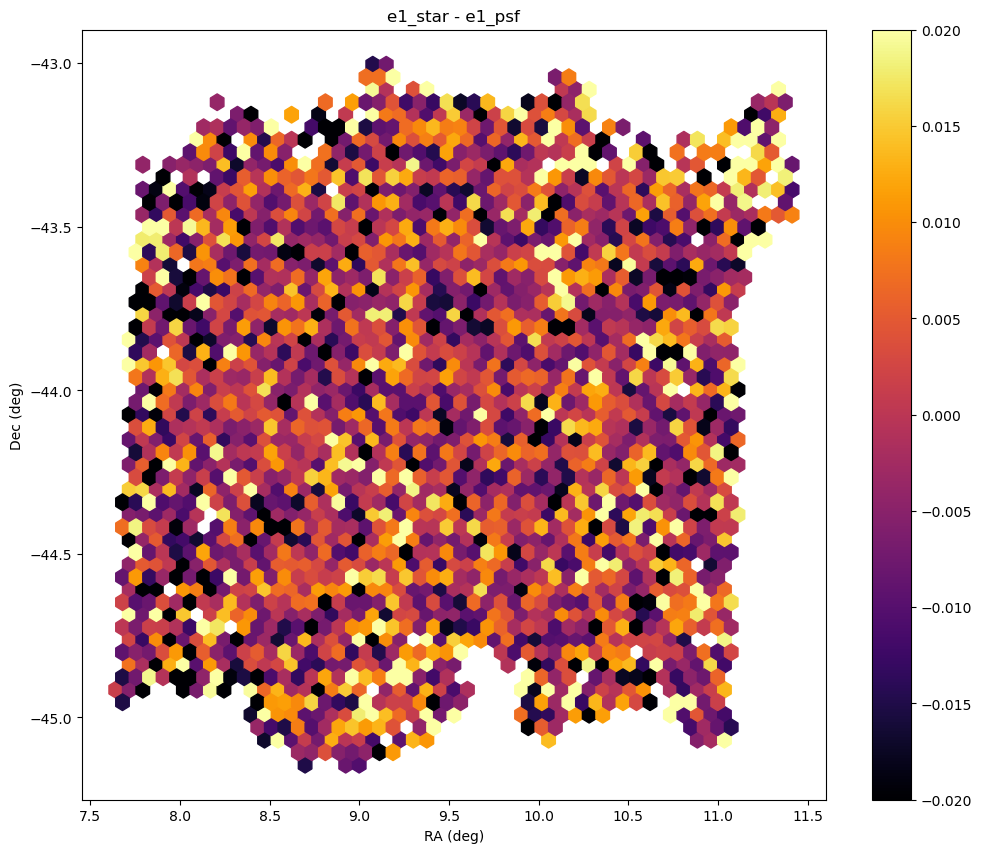

In [146]:
plt.figure(figsize=(12, 10))
plt.hexbin(ra, dec, C=de1, gridsize=50, cmap="inferno", vmin=-0.02, vmax=0.02)
plt.colorbar()
plt.title("e1_star - e1_psf")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")

Text(0, 0.5, 'Dec (deg)')

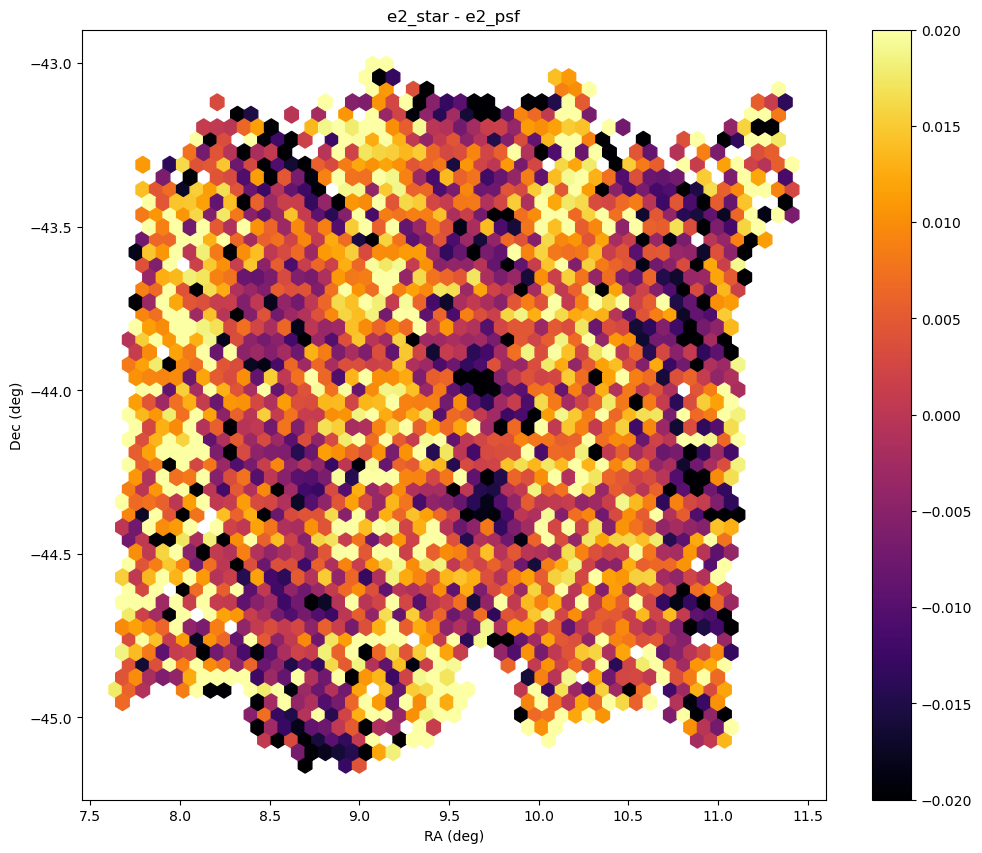

In [147]:
plt.figure(figsize=(12, 10))
plt.hexbin(ra, dec, C=de2, gridsize=50, cmap="inferno", vmin=-0.02, vmax=0.02)
plt.colorbar()
plt.title("e2_star - e2_psf")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")

Text(0, 0.5, 'Dec (deg)')

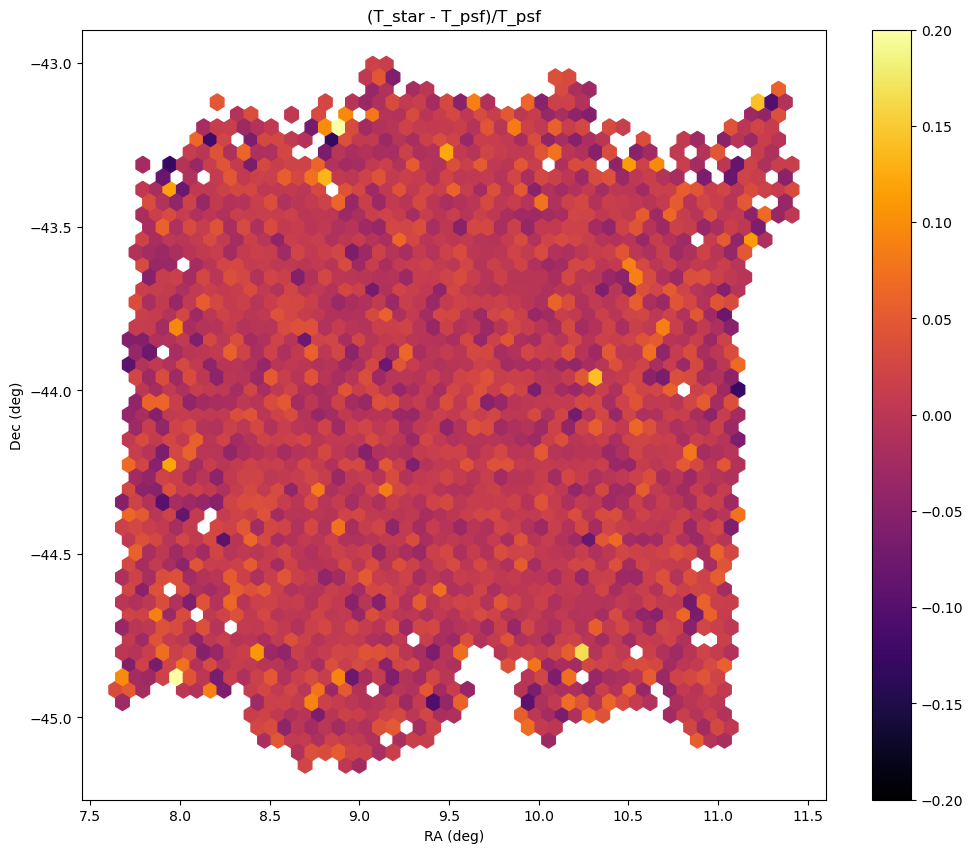

In [154]:
plt.figure(figsize=(12, 10))
plt.hexbin(ra, dec, C=dT, gridsize=50, cmap="inferno", vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.title("(T_star - T_psf)/T_psf")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")

Text(0.5, 0, 'e1')

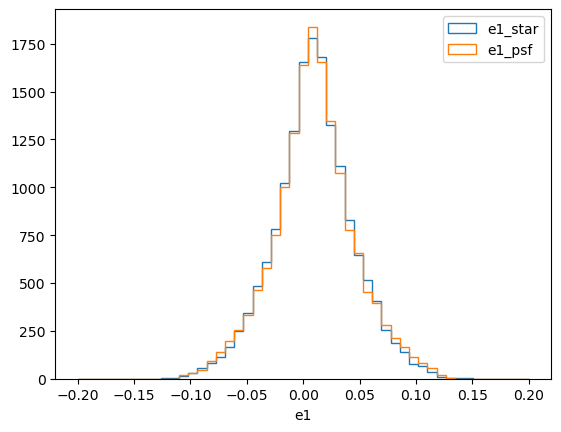

In [123]:
bins = np.linspace(-0.2, 0.2, 50)
plt.hist(e1_star, bins=bins, histtype='step', label="e1_star")
plt.hist(e1_psf, bins=bins, histtype='step', label="e1_psf")
plt.legend()
plt.xlabel("e1")

Text(0.5, 0, 'e2')

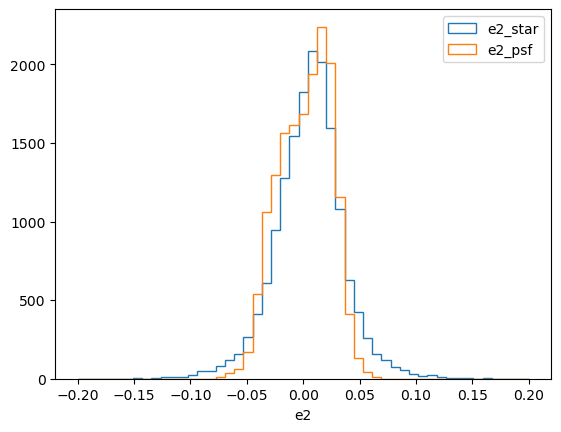

In [124]:
bins = np.linspace(-0.2, 0.2, 50)
plt.hist(e2_star, bins=bins, histtype='step', label="e2_star")
plt.hist(e2_psf, bins=bins, histtype='step', label="e2_psf")
plt.legend()
plt.xlabel("e2")

Text(0.5, 0, 'FWHM (arcsec)')

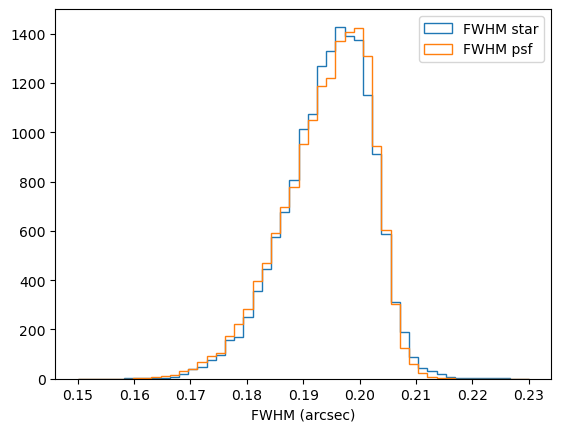

In [133]:
bins = np.linspace(0.15, 0.23, 50)
plt.hist(np.sqrt(T_star/2)*2.355, bins=bins, histtype='step', label="FWHM star")
plt.hist(np.sqrt(T_psf/2)*2.355, bins=bins, histtype='step', label="FWHM psf")
plt.legend()
plt.xlabel("FWHM (arcsec)")

Text(0.5, 0, 'de1')

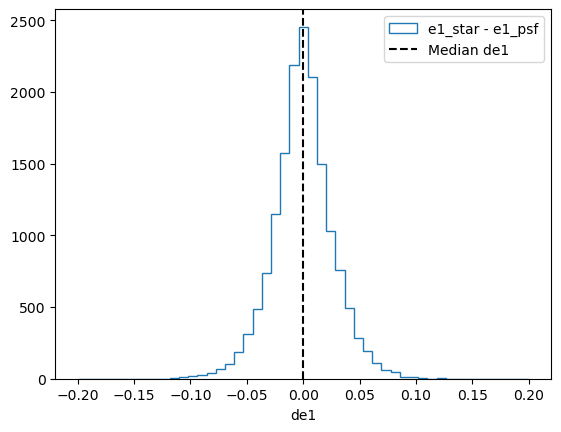

In [143]:
bins = np.linspace(-0.2, 0.2, 50)
plt.hist(de1, bins=bins, histtype='step', label="e1_star - e1_psf")
plt.axvline(np.median(de1), color='k', linestyle='--', label="Median de1")
plt.legend()
plt.xlabel("de1")

Text(0.5, 0, 'de2')

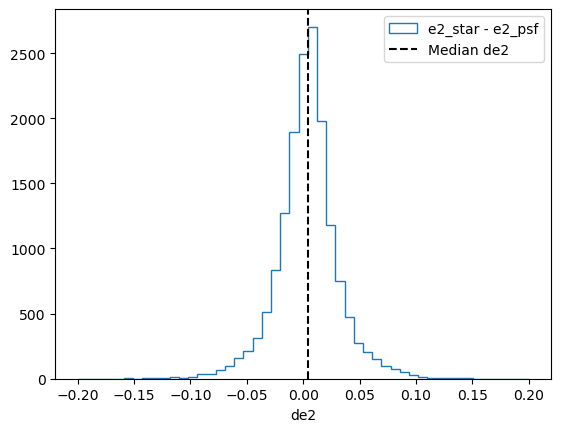

In [144]:
bins = np.linspace(-0.2, 0.2, 50)
plt.hist(de2, bins=bins, histtype='step', label="e2_star - e2_psf")
plt.axvline(np.median(de2), color='k', linestyle='--', label="Median de2")
plt.legend()
plt.xlabel("de2")

Text(0.5, 0, 'dT/T')

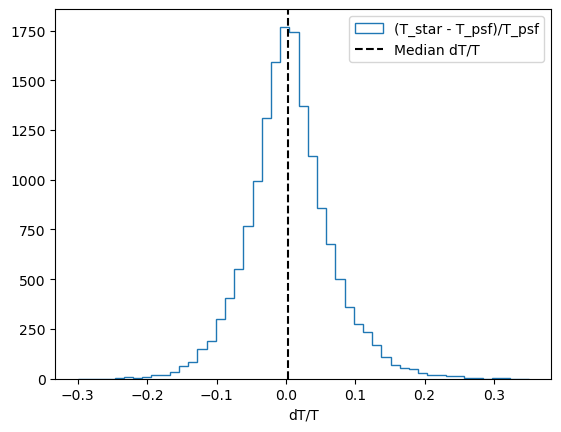

In [145]:
bins = np.linspace(-0.3, 0.35, 50)
plt.hist(dT, bins=bins, histtype='step', label="(T_star - T_psf)/T_psf")
plt.axvline(np.median(dT), color='k', linestyle='--', label="Median dT/T")
plt.legend()
plt.xlabel("dT/T")

In [107]:
cen_x = np.median(x)
cen_y = np.median(y)
print(cen_x, cen_y)

2022.352920157571 2038.7165637436683


In [108]:
TC_config_xy = {
    "x_units": "arcsec",
    "y_units": "arcsec",
    "min_sep": 0.5,
    "max_sep": 2000*0.11,
    "sep_units": "arcsec",
    "nbins": 20,
    "cross_patch_weight": "match"
}

In [109]:
tc_cat_fit_xy = tc.Catalog(
    x=(x - cen_x) * pixel_scale,
    y=(y - cen_y) * pixel_scale,
    g1=de1,
    g2=de2,
    # flag=np.invert(cat["calib_psf_used"][good_stars]),
    config=TC_config_xy,
    rng=np.random.RandomState(seed),
    npatch=n_patches,
)

# tc_cat_res_xy = tc.Catalog(
#     x=(x - cen_x) * pixel_scale,
#     y=(y - cen_y) * pixel_scale,
#     g1=de1,
#     g2=de2,
#     flag=np.invert(cat["calib_psf_reserved"][good_stars]),
#     config=TC_config_xy,
#     rng=np.random.RandomState(seed),
#     npatch=n_patches,
# )

In [110]:
rho1_fit_xy = tc.GGCorrelation(
    TC_config_xy,
    var_method="jackknife",
)
rho1_fit_xy.process(tc_cat_fit_xy)

# rho1_res_xy = tc.GGCorrelation(
#     TC_config_xy,
#     var_method="jackknife",
# )
# rho1_res_xy.process(tc_cat_res_xy)

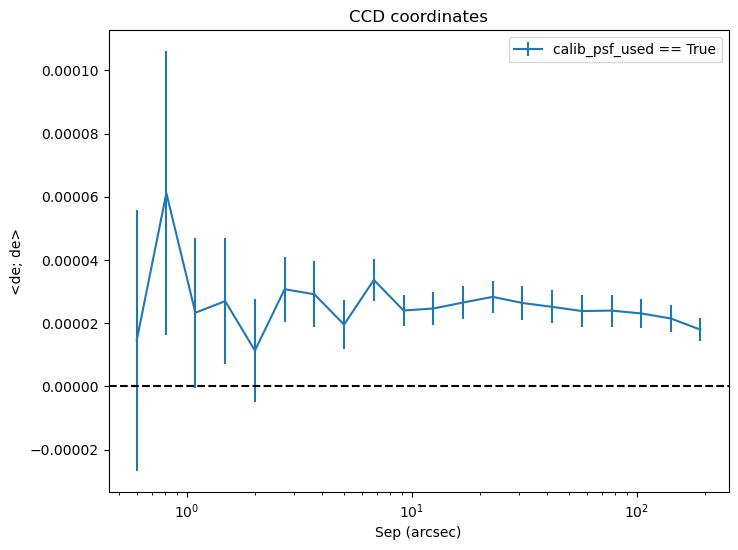

In [111]:
plt.figure(figsize=(8, 6))
plt.errorbar(rho1_fit_xy.meanr, rho1_fit_xy.xip, yerr=np.sqrt(rho1_fit_xy.varxip), label="calib_psf_used == True")
# plt.errorbar(rho1_res_xy.meanr, rho1_res_xy.xip, yerr=np.sqrt(rho1_res_xy.varxip), label="calib_psf_reserved == True")
plt.axhline(0, color="k", ls="--")
plt.xscale("log")
plt.xlabel("Sep (arcsec)")
plt.ylabel("<de; de>")
plt.title("CCD coordinates")
plt.legend()

In [112]:
TC_config_radec = {
    "ra_units": "degrees",
    "dec_units": "degrees",
    "min_sep": 0.1,
    "max_sep": 50,
    "sep_units": "arcmin",
    "nbins": 16,
    "cross_patch_weight": "match",
    # "bin_slop": 1.,
}

In [113]:
tc_cat_fit_radec = tc.Catalog(
    ra=ra,
    dec=dec,
    g1=de1,
    g2=de2,
    # flag=np.invert(cat["calib_psf_used"][good_stars]),
    config=TC_config_radec,
    rng=np.random.RandomState(seed),
    npatch=n_patches,
)

# tc_cat_res_radec = tc.Catalog(
#     ra=ra,
#     dec=dec,
#     g1=de1_rd,
#     g2=de2_rd,
#     flag=np.invert(cat["calib_psf_reserved"][good_stars]),
#     config=TC_config_radec,
#     rng=np.random.RandomState(seed),
#     patch_centers=tc_cat_fit_radec.patch_centers,
# )

In [114]:
rho1_fit_radec = tc.GGCorrelation(
    TC_config_radec,
    var_method="jackknife",
)
rho1_fit_radec.process(tc_cat_fit_radec)

# rho1_res_radec = tc.GGCorrelation(
#     TC_config_radec,
#     var_method="jackknife",
# )
# rho1_res_radec.process(tc_cat_res_radec)

# rho1_cross_radec = tc.GGCorrelation(
#     TC_config_radec,
#     var_method="jackknife",
# )
# rho1_cross_radec.process(tc_cat_res_radec, tc_cat_fit_radec)

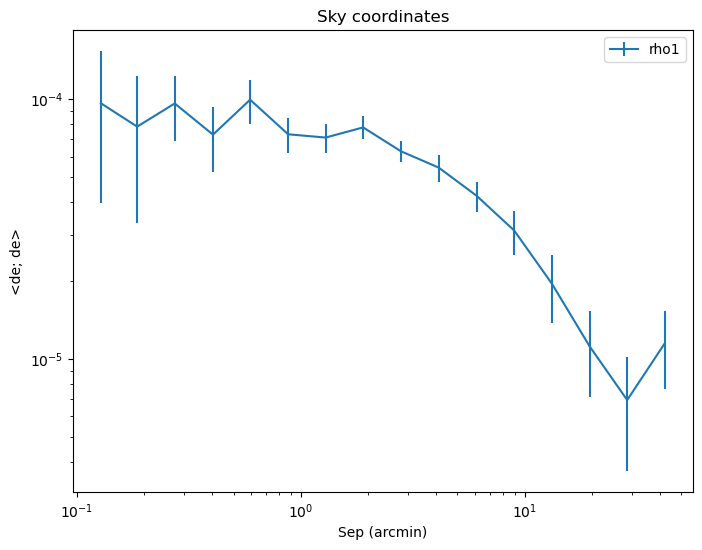

In [115]:
plt.figure(figsize=(8, 6))
plt.errorbar(rho1_fit_radec.meanr, rho1_fit_radec.xip, yerr=np.sqrt(rho1_fit_radec.varxip), label="rho1")
# plt.errorbar(rho1_res_radec.meanr, rho1_res_radec.xip, yerr=np.sqrt(rho1_res_radec.varxip), label="calib_psf_reserved == True")
plt.axhline(0, color="k", ls="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Sep (arcmin)")
plt.ylabel("<de; de>")
plt.title("Sky coordinates")
plt.legend()

## Full rho stat

In [116]:
theta_min = 0.1
theta_max = 60
nbins = 16

In [117]:
rl_fit = rho_leakage(
    ra_star=ra,
    dec_star=dec,
    g1_star=e1_star,
    g2_star=e2_star,
    T_star=T_star,
    w_star=np.ones_like(ra),
    g1_psf=e1_psf,
    g2_psf=e2_psf,
    T_psf=T_psf,
    w_psf=np.ones_like(ra),
    min_sep=theta_min,
    max_sep=theta_max,
    nbins=nbins,
    npatch=50,
)

In [118]:
rl_fit.set_rho_catalog()

mean e =  0.009594504154551303 0.0014543093450572117
std e =  0.03657533676973464 0.022929347327989423
mean T =  0.013641855070390136
std T =  0.0010649354431231338
mean de =  -0.0004363415745969097 0.003680174639831488
std de =  0.026536984024518304 0.027351693030957958
mean dT =  4.465428160669362e-05
std dT =  0.0007900349730511934
mean dT/T =  0.0015980283075766124
std dT/T =  0.06020805398850031


In [119]:
rl_fit.get_rho_corr()

Rho0...
Rho1...
Rho2...
Rho3...
Rho4...
Rho5...


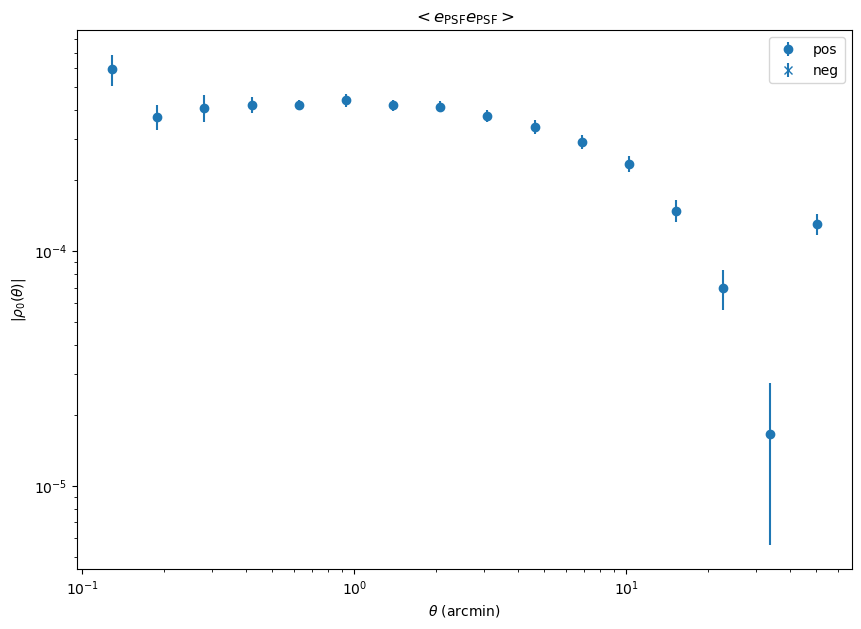

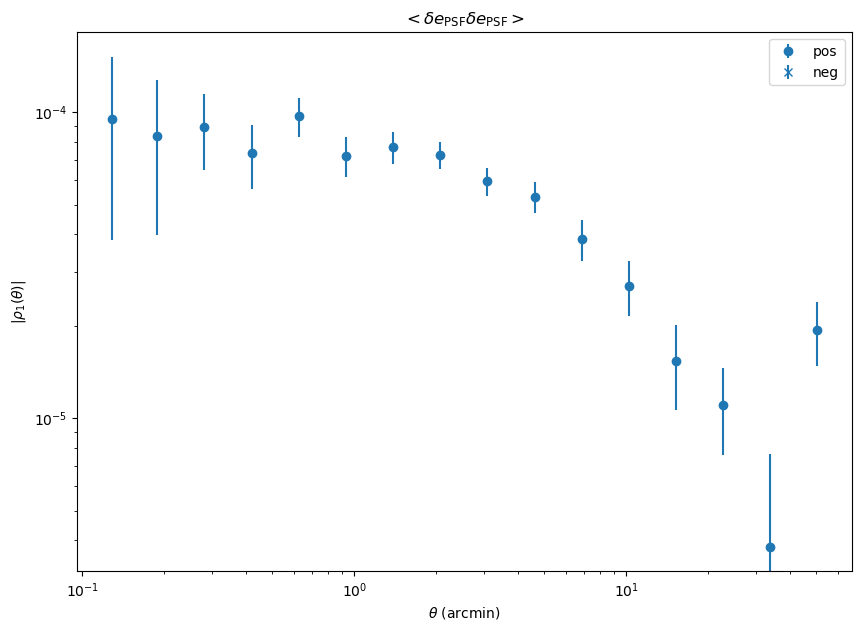

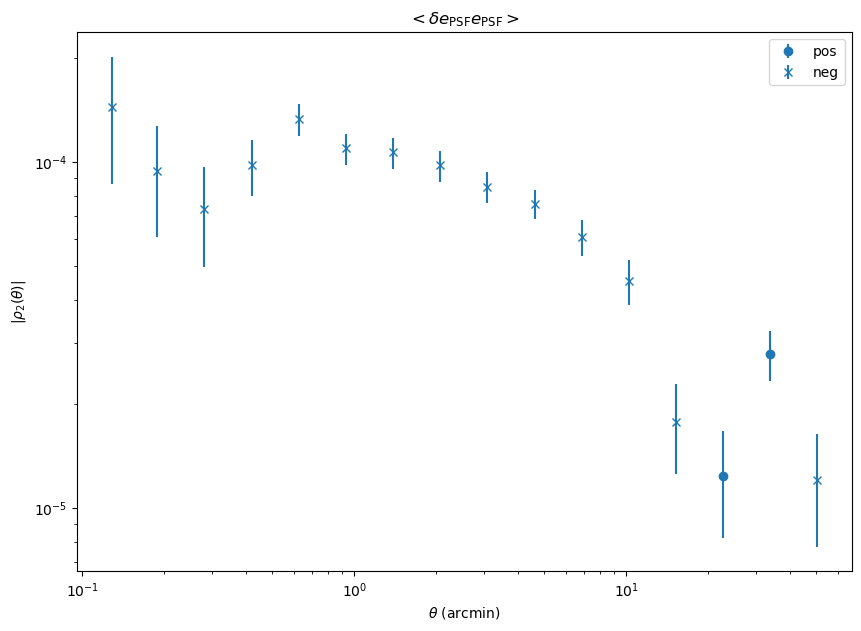

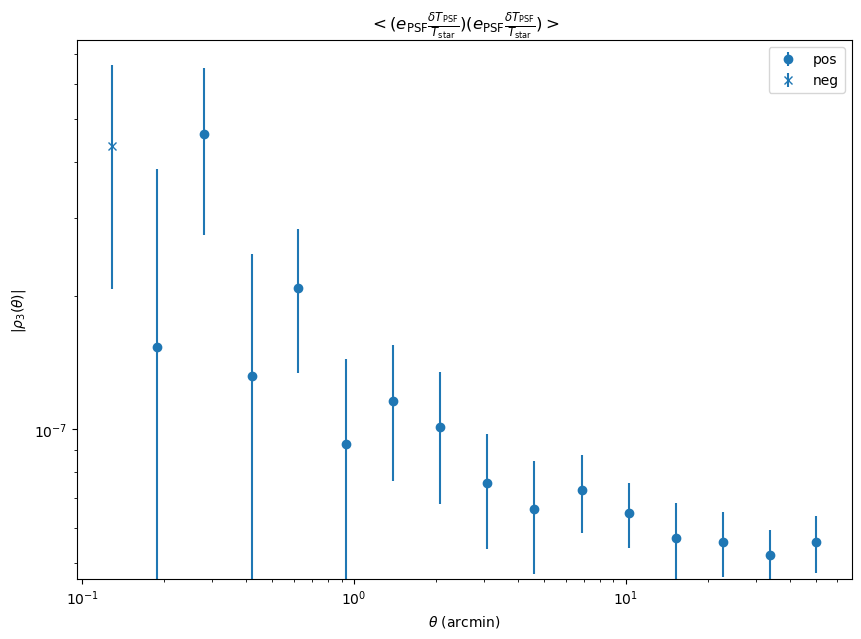

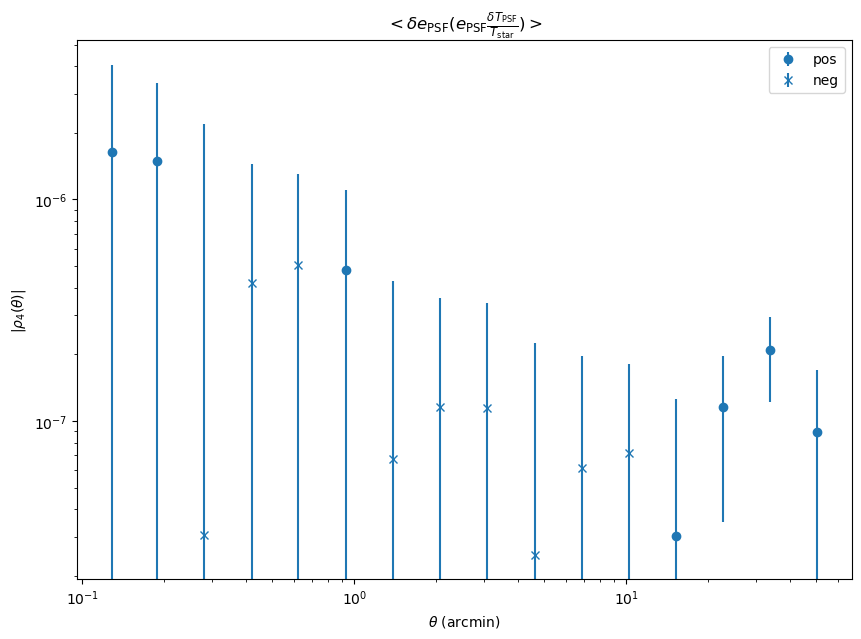

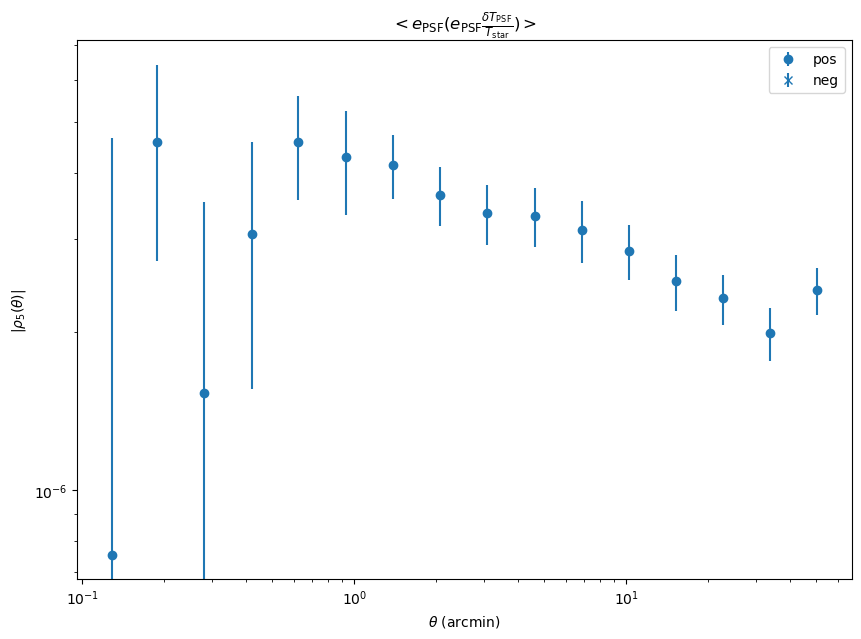

In [150]:
y_lim = [
    [1e-4, 3],
    [2e-9, 3e-4],
    [1e-6, 2e-2],
    [5e-9, 3e-4],
    [7e-9, 2e-4],
    [9e-7, 2e-2],
]

y_lim = [
    [3e-4, 1e-1],
    [7e-10, 1e-5],
    [1e-8, 5e-4],
    [5e-9, 1e-5],
    [1e-10, 5e-6],
    [1e-6, 5e-4],
]

y_lim = [
    [1e-4, 3],
    [7e-10, 3e-4],
    [1e-8, 2e-2],
    [5e-9, 3e-4],
    [1e-10, 2e-4],
    [9e-7, 2e-2],
]

eq_title = [
    r"$<e_{\mathrm{PSF}} e_{\mathrm{PSF}}>$",
    r"$<\delta e_{\mathrm{PSF}} \delta e_{\mathrm{PSF}}>$",
    r"$<\delta e_{\mathrm{PSF}} e_{\mathrm{PSF}}>$",
    r"$<(e_{\mathrm{PSF}}\frac{\delta T_{\mathrm{PSF}}}{T_{\mathrm{star}}}) (e_{\mathrm{PSF}}\frac{\delta T_{\mathrm{PSF}}}{T_{\mathrm{star}}})>$",
    r"$<\delta e_{\mathrm{PSF}} (e_{\mathrm{PSF}}\frac{\delta T_{\mathrm{PSF}}}{T_{\mathrm{star}}})>$",
    r"$<e_{\mathrm{PSF}} (e_{\mathrm{PSF}}\frac{\delta T_{\mathrm{PSF}}}{T_{\mathrm{star}}})>$",
]

for i in range(6):
    rho = getattr(rl_fit, f'rho{i}')
    # rho_res = getattr(rl_res, f'rho{i}')
    plt.figure(figsize=(10, 7))

    pos_mask = rho.xip > 0
    neg_mask = rho.xip < 0
    plt.errorbar(rho.meanr[pos_mask], np.abs(rho.xip[pos_mask]), np.sqrt(rho.varxip[pos_mask]), marker="o", linestyle="", color="C0", label="pos")
    plt.errorbar(rho.meanr[neg_mask], np.abs(rho.xip[neg_mask]), np.sqrt(rho.varxip[neg_mask]), marker="x", linestyle="", color="C0", label="neg")

    # pos_mask_res = rho_res.xip > 0
    # neg_mask_res = rho_res.xip < 0
    # plt.errorbar(rho_res.meanr[pos_mask_res]*1.05, np.abs(rho_res.xip[pos_mask_res]), np.sqrt(rho_res.varxip[pos_mask_res]), marker="o", linestyle="", color="C1", label="calib_psf_reserved == True")
    # plt.errorbar(rho_res.meanr[neg_mask_res]*1.05, np.abs(rho_res.xip[neg_mask_res]), np.sqrt(rho_res.varxip[neg_mask_res]), marker="x", linestyle="", color="C1")
    plt.xscale('log')
    plt.yscale('log')
    # plt.ylim(y_lim[i][0], y_lim[i][1])
    plt.title(eq_title[i])
    plt.xlabel(r'$\theta$ (arcmin)')
    plt.ylabel(fr'$|\rho_{i}(\theta)|$')
    plt.legend()
    plt.savefig("/Users/aguinot/Documents/roman/rho_plots/" + f'/rho_{i}.png')
    plt.show()